Dataset cargado:
   ingresos  gastos_comunes  pago_coche  gastos_otros  ahorros  vivienda  \
0      6000            1000           0           600    50000    400000   
1      6745             944         123           429    43240    636897   
2      6455            1033          98           795    57463    321779   
3      7098            1278          15           254    54506    660933   
4      6167             863         223           520    41512    348932   

   estado_civil  hijos  trabajo  comprar  
0             0      2        2        1  
1             1      3        6        0  
2             2      1        8        1  
3             0      0        3        0  
4             0      0        3        1  

Distribución de clases:
comprar
0    135
1     67
Name: count, dtype: int64

Características seleccionadas: ['ingresos', 'ahorros', 'hijos', 'trabajo', 'financiar']

Precisión Train: 0.88
Precisión Test: 0.83

Reporte de clasificación:
              precision    reca

<Figure size 800x600 with 0 Axes>

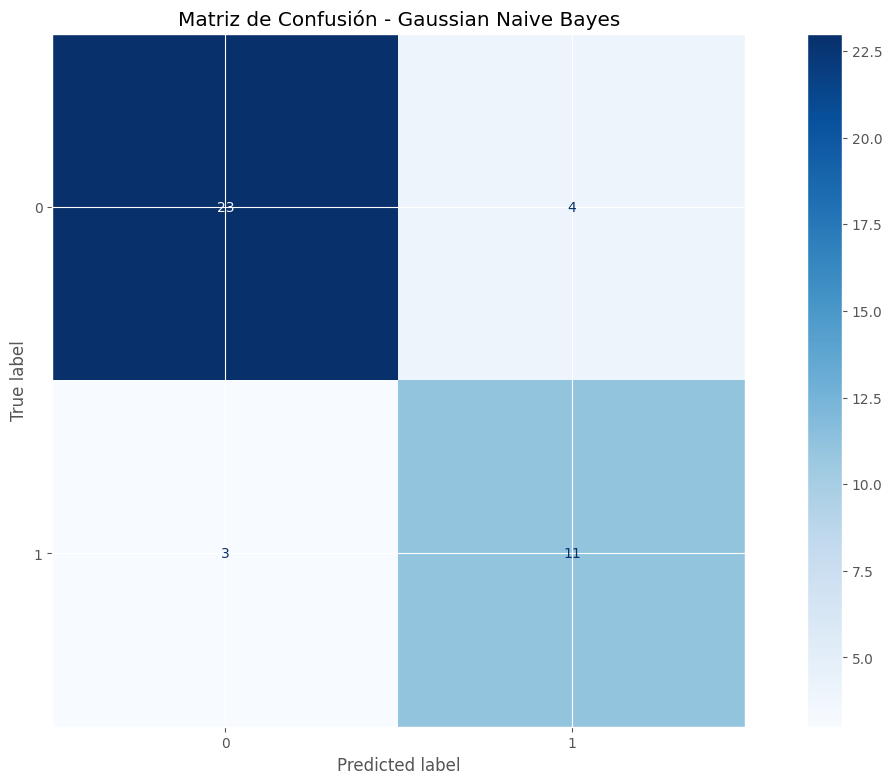

<Figure size 800x600 with 0 Axes>

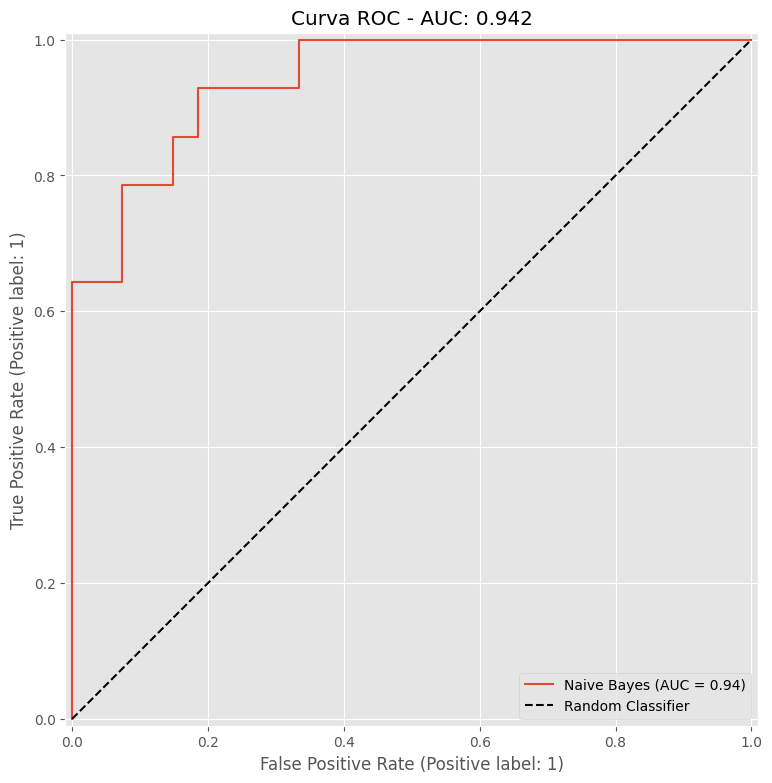


AUC Score: 0.942

Predicciones de prueba:
Caso 1 (bajos ingresos): Alquilar
Caso 2 (buenos ingresos): Comprar


In [1]:
# Instalación de librerías (ejecutar primero si no están)
!pip install pandas numpy matplotlib seaborn scikit-learn

# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay
import warnings
warnings.filterwarnings('ignore')

# Cargar dataset desde la URL proporcionada
url = "https://raw.githubusercontent.com/Darwin2016/dataset2022/main/dataSETS/comprar_alquilar2024.csv"
dataframe = pd.read_csv(url)
print("Dataset cargado:")
print(dataframe.head())
print("\nDistribución de clases:")
print(dataframe['comprar'].value_counts())

# Preprocesamiento (igual que el artículo)
dataframe['gastos'] = (dataframe['gastos_comunes'] + dataframe['gastos_otros'] + dataframe['pago_coche'])
dataframe['financiar'] = dataframe['vivienda'] - dataframe['ahorros']
reduced = dataframe.drop(['gastos_comunes', 'gastos_otros', 'pago_coche'], axis=1)

# Feature Selection: seleccionar las 5 mejores características
X = reduced.drop(['comprar'], axis=1)
y = reduced['comprar']
selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support(indices=True)]
print(f"\nCaracterísticas seleccionadas: {list(selected_features)}")

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    reduced[selected_features], y, test_size=0.2, random_state=6, stratify=y
)

# Entrenar modelo Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)
y_pred_proba = gnb.predict_proba(X_test)[:, 1]  # Probabilidades para ROC

# Accuracy
train_acc = gnb.score(X_train, y_train)
test_acc = gnb.score(X_test, y_test)
print(f"\nPrecisión Train: {train_acc:.2f}")
print(f"Precisión Test: {test_acc:.2f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

# 1. MATRIZ DE CONFUSIÓN (gráfica)
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('Matriz de Confusión - Gaussian Naive Bayes')
plt.show()

# 2. CURVA ROC y AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_pred_proba, name="Naive Bayes")
plt.title(f'Curva ROC - AUC: {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.legend()
plt.show()

print(f"\nAUC Score: {roc_auc:.3f}")

# 3. Predicciones de prueba (ejemplos del artículo)
test_cases = np.array([
    [2000, 5000, 0, 5, 200000-5000],  # Alquilar
    [6000, 34000, 2, 5, 320000-34000]  # Comprar
], dtype=float)
predictions = gnb.predict(test_cases)
print("\nPredicciones de prueba:")
print("Caso 1 (bajos ingresos):", "Alquilar" if predictions[0] == 0 else "Comprar")
print("Caso 2 (buenos ingresos):", "Alquilar" if predictions[1] == 0 else "Comprar")
